Imports

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Synthetic dataset (identical setup to your QA-PINN)

In [2]:
x_min, x_max = -1.0, 1.0
t_min, t_max = 0.0, 1.0
nu = 0.01 / np.pi

def initial_condition(x):
    return -np.sin(np.pi * x)

# Collocation points (physics residual points)
N_f = 500
x_f = np.random.uniform(x_min, x_max, N_f).reshape(-1, 1)
t_f = np.random.uniform(t_min, t_max, N_f).reshape(-1, 1)

# Initial condition points
N_0 = 100
x_0 = np.random.uniform(x_min, x_max, N_0).reshape(-1, 1)
t_0 = np.zeros((N_0, 1))
u_0 = initial_condition(x_0)

# Boundary condition points
N_b = 100
t_b = np.random.uniform(t_min, t_max, N_b).reshape(-1, 1)
x_b_left  = np.full((N_b, 1), x_min)
x_b_right = np.full((N_b, 1), x_max)

# Convert to TF tensors
X_f = tf.convert_to_tensor(x_f, dtype=tf.float32)
T_f = tf.convert_to_tensor(t_f, dtype=tf.float32)
X_0 = tf.convert_to_tensor(x_0, dtype=tf.float32)
T_0 = tf.convert_to_tensor(t_0, dtype=tf.float32)
U_0 = tf.convert_to_tensor(u_0, dtype=tf.float32)
X_bl = tf.convert_to_tensor(x_b_left, dtype=tf.float32)
T_bl = tf.convert_to_tensor(t_b, dtype=tf.float32)
X_br = tf.convert_to_tensor(x_b_right, dtype=tf.float32)
T_br = tf.convert_to_tensor(t_b, dtype=tf.float32)

print("Data ready:", X_f.shape, X_0.shape, X_bl.shape)

Data ready: (500, 1) (100, 1) (100, 1)


Classical PINN model architecture

In [3]:
def build_pinn(hidden_dim=32, n_hidden_layers=4):
    inputs = tf.keras.Input(shape=(2,))  # (x, t)
    x = inputs
    for _ in range(n_hidden_layers):
        x = tf.keras.layers.Dense(hidden_dim, activation='tanh')(x)
    outputs = tf.keras.layers.Dense(1)(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

pinn_model = build_pinn()
pinn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,297 (12.88 KB)

 Trainable params: 3,297 (12.88 KB)

 Non-trainable params: 0 (0.00 B)

Physics-informed loss (Burgers' equation) using TF GradientTape

In [4]:
def burgers_residual(model, x, t, nu):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)
        tape2.watch(t)
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(x)
            tape1.watch(t)
            inputs = tf.concat([x, t], axis=1)
            u = model(inputs)
        u_x = tape1.gradient(u, x)
        u_t = tape1.gradient(u, t)
    u_xx = tape2.gradient(u_x, x)
    del tape1, tape2

    f = u_t + u * u_x - nu * u_xx
    return f

def compute_loss(model):
    f_pred = burgers_residual(model, X_f, T_f, nu)
    loss_f = tf.reduce_mean(tf.square(f_pred))

    u0_pred = model(tf.concat([X_0, T_0], axis=1))
    loss_0 = tf.reduce_mean(tf.square(u0_pred - U_0))

    ubl_pred = model(tf.concat([X_bl, T_bl], axis=1))
    ubr_pred = model(tf.concat([X_br, T_br], axis=1))
    loss_b = tf.reduce_mean(tf.square(ubl_pred)) + tf.reduce_mean(tf.square(ubr_pred))

    total_loss = loss_f + loss_0 + loss_b
    return total_loss, loss_f, loss_0, loss_b

Training loop

In [5]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
epochs = 3000  # classical PINN trains fast, so more epochs is fine
loss_history = []

start = time.time()
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss, lf, l0, lb = compute_loss(pinn_model)
    grads = tape.gradient(loss, pinn_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, pinn_model.trainable_variables))
    loss_history.append(loss.numpy())

    if epoch % 200 == 0:
        elapsed = time.time() - start
        print(f"Epoch {epoch:4d} | Total: {loss.numpy():.6f} | "
              f"PDE: {lf.numpy():.6f} | IC: {l0.numpy():.6f} | BC: {lb.numpy():.6f} | "
              f"Elapsed: {elapsed:.1f}s")

pinn_train_time = time.time() - start
print("Training complete. Total time:", pinn_train_time, "seconds")

Epoch    0 | Total: 0.647191 | PDE: 0.036014 | IC: 0.570668 | BC: 0.040509 | Elapsed: 0.4s
Epoch  200 | Total: 0.155614 | PDE: 0.062845 | IC: 0.086309 | BC: 0.006460 | Elapsed: 25.2s
Epoch  400 | Total: 0.149478 | PDE: 0.068609 | IC: 0.069873 | BC: 0.010996 | Elapsed: 48.0s
Epoch  600 | Total: 0.105128 | PDE: 0.047121 | IC: 0.055985 | BC: 0.002022 | Elapsed: 72.0s
Epoch  800 | Total: 0.088526 | PDE: 0.039934 | IC: 0.047571 | BC: 0.001021 | Elapsed: 95.5s
Epoch 1000 | Total: 0.076320 | PDE: 0.029573 | IC: 0.045848 | BC: 0.000899 | Elapsed: 118.8s
Epoch 1200 | Total: 0.068193 | PDE: 0.026634 | IC: 0.041263 | BC: 0.000296 | Elapsed: 141.5s
Epoch 1400 | Total: 0.064061 | PDE: 0.023909 | IC: 0.039967 | BC: 0.000185 | Elapsed: 165.1s
Epoch 1600 | Total: 0.061502 | PDE: 0.022813 | IC: 0.038515 | BC: 0.000174 | Elapsed: 188.4s
Epoch 1800 | Total: 0.058635 | PDE: 0.021164 | IC: 0.037305 | BC: 0.000166 | Elapsed: 211.6s
Epoch 2000 | Total: 0.056257 | PDE: 0.020173 | IC: 0.035937 | BC: 0.000147 |

Loss curve

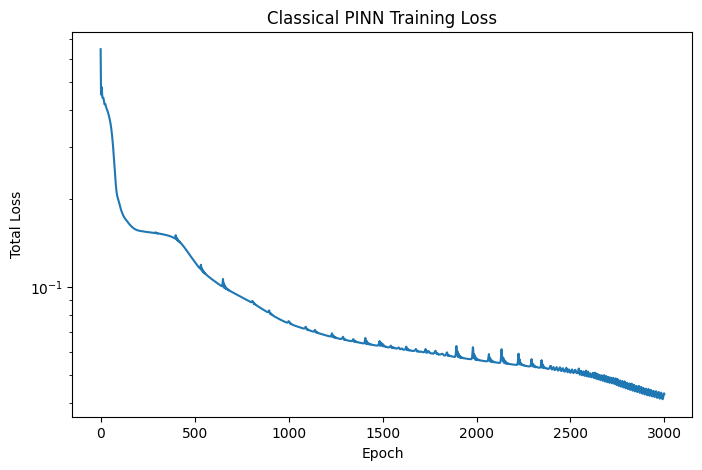

In [6]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Classical PINN Training Loss")
plt.yscale("log")
plt.show()

Predictions on the test grid (same grid as QA-PINN)

In [7]:
x_test = np.linspace(x_min, x_max, 100)
t_test = np.linspace(t_min, t_max, 100)
X, T = np.meshgrid(x_test, t_test)

def predict_pinn(model, x, t):
    x_flat = x.flatten().reshape(-1, 1).astype(np.float32)
    t_flat = t.flatten().reshape(-1, 1).astype(np.float32)
    inputs = np.hstack([x_flat, t_flat])
    u_pred = model.predict(inputs, verbose=0)
    return u_pred.flatten()

U_pinn = predict_pinn(pinn_model, X, T).reshape(X.shape)
np.save("U_pinn.npy", U_pinn)
print("Saved U_pinn.npy, shape:", U_pinn.shape)

Saved U_pinn.npy, shape: (100, 100)


Heatmap and 3D surface (for your own PINN visualization objective)

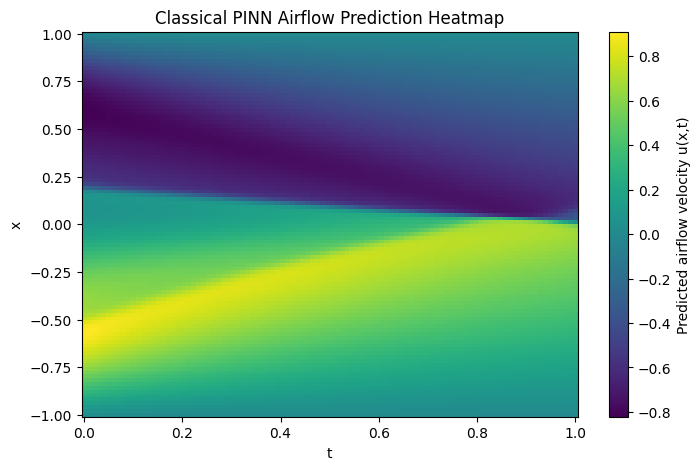

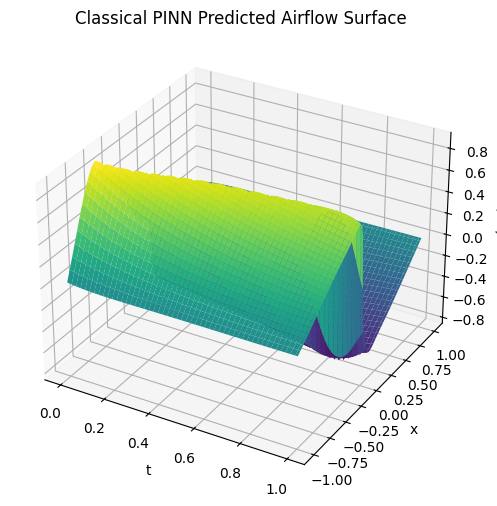

In [8]:
plt.figure(figsize=(8,5))
plt.pcolormesh(t_test, x_test, U_pinn.T, cmap='viridis', shading='auto')
plt.colorbar(label='Predicted airflow velocity u(x,t)')
plt.xlabel('t'); plt.ylabel('x')
plt.title('Classical PINN Airflow Prediction Heatmap')
plt.show()

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T, X, U_pinn, cmap='viridis')
ax.set_xlabel('t'); ax.set_ylabel('x'); ax.set_zlabel('u(x,t)')
ax.set_title('Classical PINN Predicted Airflow Surface')
plt.show()

1D visualization: airflow profile at fixed time

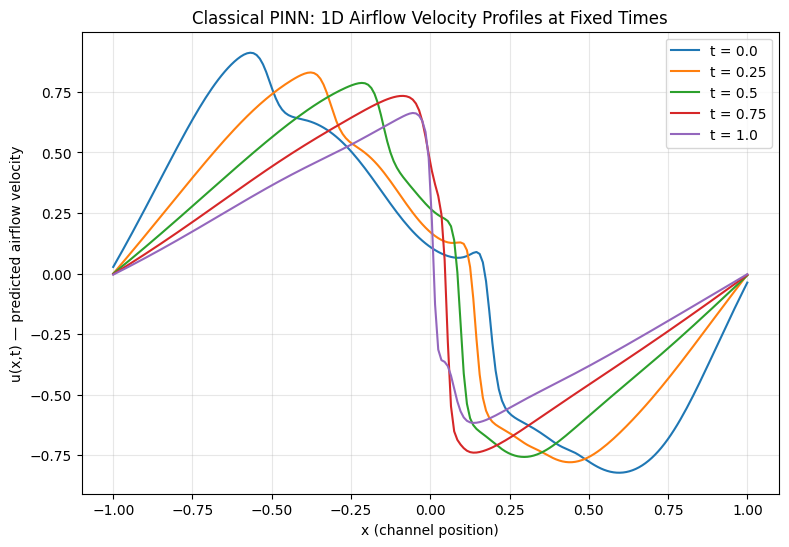

In [9]:
snapshot_times = [0.0, 0.25, 0.5, 0.75, 1.0]

plt.figure(figsize=(9,6))
for st in snapshot_times:
    x_line = np.linspace(x_min, x_max, 200).reshape(-1, 1).astype(np.float32)
    t_line = np.full_like(x_line, st, dtype=np.float32)
    inputs = np.hstack([x_line, t_line])
    u_line = pinn_model.predict(inputs, verbose=0).flatten()
    plt.plot(x_line, u_line, label=f"t = {st}")

plt.xlabel("x (channel position)")
plt.ylabel("u(x,t) — predicted airflow velocity")
plt.title("Classical PINN: 1D Airflow Velocity Profiles at Fixed Times")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

1D visualization: airflow at fixed spatial locations over time

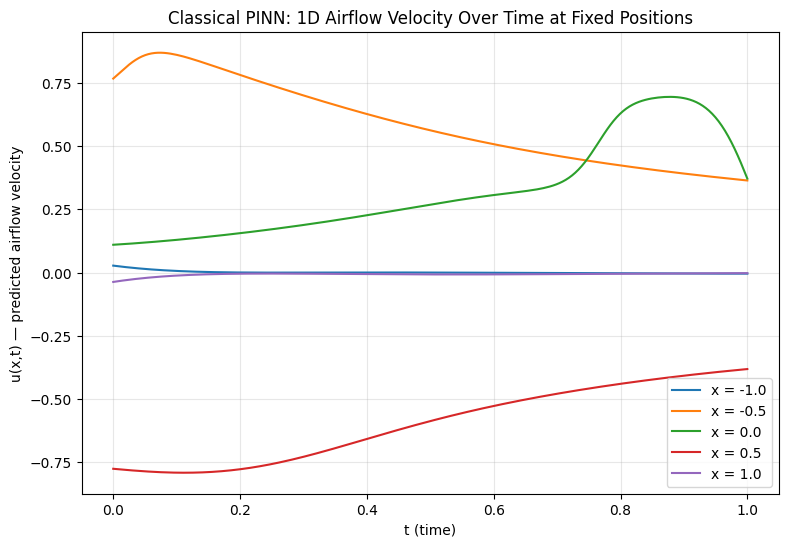

In [10]:
snapshot_positions = [-1.0, -0.5, 0.0, 0.5, 1.0]

plt.figure(figsize=(9,6))
for sx in snapshot_positions:
    t_line = np.linspace(t_min, t_max, 200).reshape(-1, 1).astype(np.float32)
    x_line = np.full_like(t_line, sx, dtype=np.float32)
    inputs = np.hstack([x_line, t_line])
    u_line = pinn_model.predict(inputs, verbose=0).flatten()
    plt.plot(t_line, u_line, label=f"x = {sx}")

plt.xlabel("t (time)")
plt.ylabel("u(x,t) — predicted airflow velocity")
plt.title("Classical PINN: 1D Airflow Velocity Over Time at Fixed Positions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

2D contour plot (alternative to heatmap, often clearer for reports)

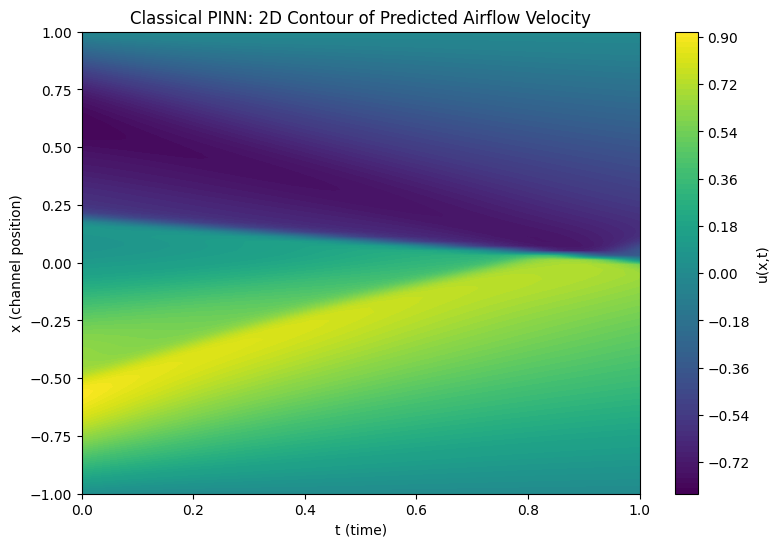

In [11]:
plt.figure(figsize=(9,6))
contour = plt.contourf(T, X, U_pinn, levels=100, cmap='viridis')
plt.colorbar(contour, label='u(x,t)')
plt.xlabel('t (time)')
plt.ylabel('x (channel position)')
plt.title('Classical PINN: 2D Contour of Predicted Airflow Velocity')
plt.show()

Combined summary figure

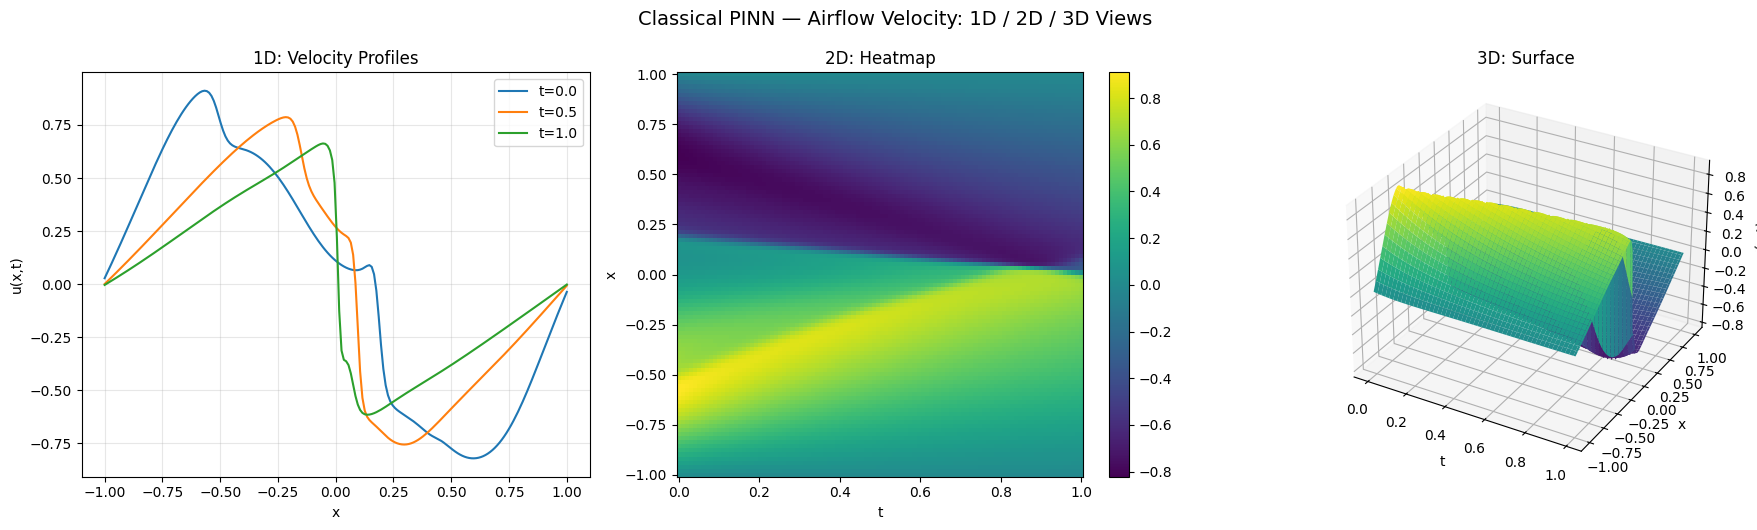

In [12]:
fig = plt.figure(figsize=(18, 5))

# 1D subplot
ax1 = fig.add_subplot(1, 3, 1)
for st in [0.0, 0.5, 1.0]:
    x_line = np.linspace(x_min, x_max, 200).reshape(-1, 1).astype(np.float32)
    t_line = np.full_like(x_line, st, dtype=np.float32)
    inputs = np.hstack([x_line, t_line])
    u_line = pinn_model.predict(inputs, verbose=0).flatten()
    ax1.plot(x_line, u_line, label=f"t={st}")
ax1.set_xlabel("x"); ax1.set_ylabel("u(x,t)")
ax1.set_title("1D: Velocity Profiles")
ax1.legend(); ax1.grid(alpha=0.3)

# 2D subplot
ax2 = fig.add_subplot(1, 3, 2)
im = ax2.pcolormesh(t_test, x_test, U_pinn.T, cmap='viridis', shading='auto')
ax2.set_xlabel("t"); ax2.set_ylabel("x")
ax2.set_title("2D: Heatmap")
plt.colorbar(im, ax=ax2)

# 3D subplot
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
ax3.plot_surface(T, X, U_pinn, cmap='viridis')
ax3.set_xlabel("t"); ax3.set_ylabel("x"); ax3.set_zlabel("u(x,t)")
ax3.set_title("3D: Surface")

plt.tight_layout()
plt.suptitle("Classical PINN — Airflow Velocity: 1D / 2D / 3D Views", y=1.05, fontsize=14)
plt.show()